In [14]:
import os, sys

DATA_PATH = '../data/processed_v2.csv'

SRC_PATH = os.path.abspath('../src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f'DATA_PATH: {DATA_PATH}')
print(f'SRC_PATH:  {SRC_PATH}')

DATA_PATH: ../data/processed_v2.csv
SRC_PATH:  /Users/anastasiiakostyrka/Desktop/labs/src


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from svm_experiments import load_and_prepare

# Завантаження та підготовка
df = load_and_prepare(DATA_PATH)
print(f'Розмічених рядків: {len(df)}')
print(f'Розподіл класів:\n{df["label"].value_counts()}')
print(f'\nПропорції: {df["label"].value_counts(normalize=True).round(3).to_dict()}')

X = df['text_clean']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# Перевірка розподілу по сплітах
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    vc = yy.value_counts(normalize=True)
    print(f'{name}: class0={vc.get(0,0):.3f}, class1={vc.get(1,0):.3f}')

Розмічених рядків: 4387
Розподіл класів:
label
1    2485
0    1902
Name: count, dtype: int64

Пропорції: {1: 0.566, 0: 0.434}

Train: 3070 | Val: 658 | Test: 659
train: class0=0.434, class1=0.566
val: class0=0.433, class1=0.567
test: class0=0.434, class1=0.566


In [4]:
from svm_experiments import run_logreg_baseline

ref = run_logreg_baseline(
    X_train, y_train, X_val, y_val,
    class_weight='balanced',
    label='LogReg word(1,2) balanced [ЛР6 ref]'
)

print(f"=== {ref['label']} ===")
print(f"Accuracy:  {ref['accuracy']:.4f}")
print(f"Macro-F1:  {ref['macro_f1']:.4f}")
print(f"\n{ref['report']}")

=== LogReg word(1,2) balanced [ЛР6 ref] ===
Accuracy:  0.9012
Macro-F1:  0.8993

              precision    recall  f1-score   support

           0     0.8901    0.8807    0.8854       285
           1     0.9096    0.9169    0.9132       373

    accuracy                         0.9012       658
   macro avg     0.8998    0.8988    0.8993       658
weighted avg     0.9011    0.9012    0.9012       658



In [5]:
from svm_experiments import run_linear_svc

# 5a. SVM word без balancing
svm_word = run_linear_svc(
    X_train, y_train, X_val, y_val,
    variant='word', class_weight=None,
    label='LinearSVC word(1,2)'
)

# 5b. SVM word з balanced
svm_word_bal = run_linear_svc(
    X_train, y_train, X_val, y_val,
    variant='word', class_weight='balanced',
    label='LinearSVC word(1,2) balanced'
)

for r in [svm_word, svm_word_bal]:
    print(f"=== {r['label']} ===")
    print(f"Accuracy: {r['accuracy']:.4f} | Macro-F1: {r['macro_f1']:.4f}")
    print(r['report'])

=== LinearSVC word(1,2) ===
Accuracy: 0.9088 | Macro-F1: 0.9070
              precision    recall  f1-score   support

           0     0.9004    0.8877    0.8940       285
           1     0.9151    0.9249    0.9200       373

    accuracy                         0.9088       658
   macro avg     0.9077    0.9063    0.9070       658
weighted avg     0.9087    0.9088    0.9087       658

=== LinearSVC word(1,2) balanced ===
Accuracy: 0.9043 | Macro-F1: 0.9027
              precision    recall  f1-score   support

           0     0.8828    0.8982    0.8904       285
           1     0.9212    0.9088    0.9150       373

    accuracy                         0.9043       658
   macro avg     0.9020    0.9035    0.9027       658
weighted avg     0.9045    0.9043    0.9043       658



In [6]:
# 6a. Тільки char_wb(3,5)
svm_char = run_linear_svc(
    X_train, y_train, X_val, y_val,
    variant='char', class_weight='balanced',
    label='LinearSVC char_wb(3,5) balanced'
)

# 6b. Word + char (FeatureUnion)
svm_word_char = run_linear_svc(
    X_train, y_train, X_val, y_val,
    variant='word+char', class_weight='balanced',
    label='LinearSVC word(1,2)+char_wb(3,5) balanced'
)

for r in [svm_char, svm_word_char]:
    print(f"=== {r['label']} ===")
    print(f"Accuracy: {r['accuracy']:.4f} | Macro-F1: {r['macro_f1']:.4f}")
    print(r['report'])
    
print('=== Порівняння word vs word+char ===')
delta = svm_word_char['macro_f1'] - svm_word_bal['macro_f1']
print(f"Приріст Macro-F1 від char-ngrams: {delta:+.4f}")

=== LinearSVC char_wb(3,5) balanced ===
Accuracy: 0.9225 | Macro-F1: 0.9212
              precision    recall  f1-score   support

           0     0.9062    0.9158    0.9110       285
           1     0.9351    0.9276    0.9314       373

    accuracy                         0.9225       658
   macro avg     0.9207    0.9217    0.9212       658
weighted avg     0.9226    0.9225    0.9225       658

=== LinearSVC word(1,2)+char_wb(3,5) balanced ===
Accuracy: 0.9240 | Macro-F1: 0.9226
              precision    recall  f1-score   support

           0     0.9152    0.9088    0.9120       285
           1     0.9307    0.9357    0.9332       373

    accuracy                         0.9240       658
   macro avg     0.9229    0.9222    0.9226       658
weighted avg     0.9240    0.9240    0.9240       658

=== Порівняння word vs word+char ===
Приріст Macro-F1 від char-ngrams: +0.0199


In [7]:
import pandas as pd

results = [ref, svm_word, svm_word_bal, svm_char, svm_word_char]

rows = []
for r in results:
    rows.append({
        'Model': r['label'],
        'Accuracy': round(r['accuracy'], 4),
        'Macro-F1': round(r['macro_f1'], 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

print('\n--- Висновок про дисбаланс ---')
diff = svm_word_bal['macro_f1'] - svm_word['macro_f1']
print(f"class_weight balanced дав приріст Macro-F1: {diff:+.4f}")
if diff > 0:
    print('Балансування допомогло. Рекомендовано використовувати balanced.')
else:
    print('Балансування не дало приросту. Дисбаланс, можливо, незначний.')

                                    Model  Accuracy  Macro-F1
      LogReg word(1,2) balanced [ЛР6 ref]    0.9012    0.8993
                      LinearSVC word(1,2)    0.9088    0.9070
             LinearSVC word(1,2) balanced    0.9043    0.9027
          LinearSVC char_wb(3,5) balanced    0.9225    0.9212
LinearSVC word(1,2)+char_wb(3,5) balanced    0.9240    0.9226

--- Висновок про дисбаланс ---
class_weight balanced дав приріст Macro-F1: -0.0043
Балансування не дало приросту. Дисбаланс, можливо, незначний.


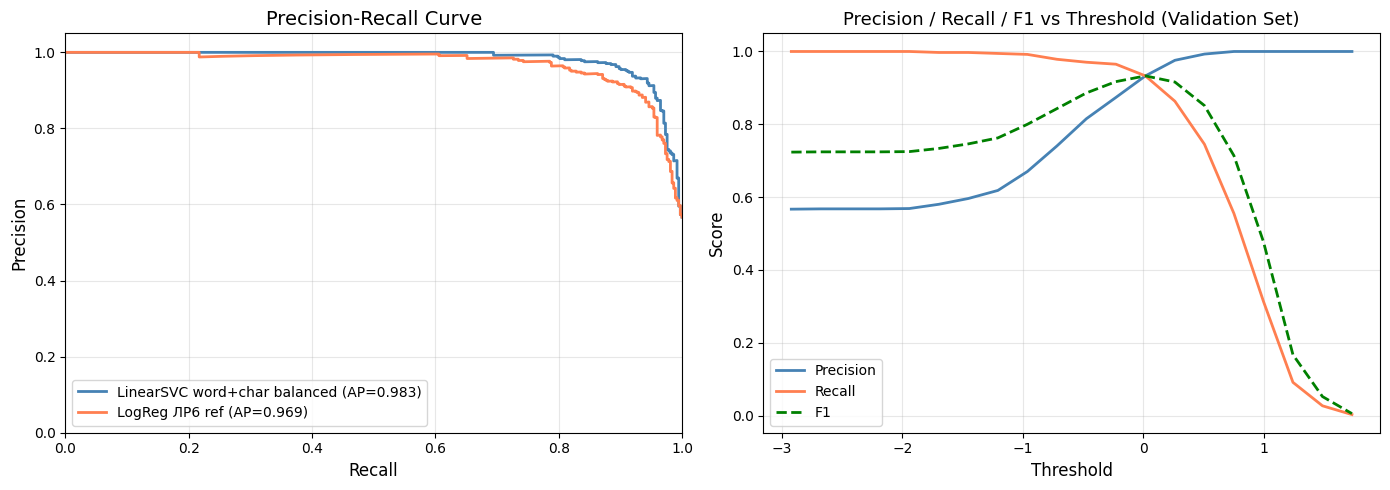

AP (Average Precision) найкращої моделі: 0.9827


In [8]:
import matplotlib.pyplot as plt
from threshold_eval import (
    plot_pr_curve, plot_threshold_metrics,
    find_best_threshold_f1, find_best_threshold_recall,
    evaluate_thresholds, apply_threshold
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

best_pipe = svm_word_char['pipe']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1, prec, rec, thr, ap = plot_pr_curve(
    best_pipe, X_val, y_val,
    label='LinearSVC word+char balanced',
    ax=axes[0]
)
# Також референс LogReg
plot_pr_curve(
    ref['pipe'], X_val, y_val,
    label='LogReg ЛР6 ref',
    ax=axes[0], color='coral'
)

ax2, thresh_df = plot_threshold_metrics(best_pipe, X_val, y_val, ax=axes[1])

plt.tight_layout()
plt.savefig('../docs/pr_curve_lab7.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'AP (Average Precision) найкращої моделі: {ap:.4f}')

In [9]:
t_f1, best_f1 = find_best_threshold_f1(best_pipe, X_val, y_val)
print(f'Поріг з макс. F1 на val: {t_f1:.4f} (F1={best_f1:.4f})')

t_recall = find_best_threshold_recall(best_pipe, X_val, y_val, min_precision=0.75)
print(f'Поріг recall-first (prec>=0.75) на val: {t_recall:.4f}')

print('\n=== Порівняння порогів на Validation Set ===')
for name, t in [('default (0.0)', 0.0), (f'best-F1 ({t_f1:.3f})', t_f1), (f'recall-first ({t_recall:.3f})', t_recall)]:
    y_pred_t = apply_threshold(best_pipe, X_val, t)
    acc = accuracy_score(y_val, y_pred_t)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    print(f'  Threshold {name}: Accuracy={acc:.4f} | Macro-F1={f1:.4f}')

CHOSEN_THRESHOLD = t_recall
print(f'\n>>> Обраний поріг: {CHOSEN_THRESHOLD:.4f} (recall-first логіка)')
print('Обґрунтування: для задачі моніторингу скарг пропустити негативний текст'
      ' (FN) дорожче, ніж помилково відмітити нейтральний (FP).')

Поріг з макс. F1 на val: -0.0083 (F1=0.9374)
Поріг recall-first (prec>=0.75) на val: -0.6961

=== Порівняння порогів на Validation Set ===
  Threshold default (0.0): Accuracy=0.9240 | Macro-F1=0.9226
  Threshold best-F1 (-0.008): Accuracy=0.9286 | Macro-F1=0.9271
  Threshold recall-first (-0.696): Accuracy=0.8024 | Macro-F1=0.7823

>>> Обраний поріг: -0.6961 (recall-first логіка)
Обґрунтування: для задачі моніторингу скарг пропустити негативний текст (FN) дорожче, ніж помилково відмітити нейтральний (FP).


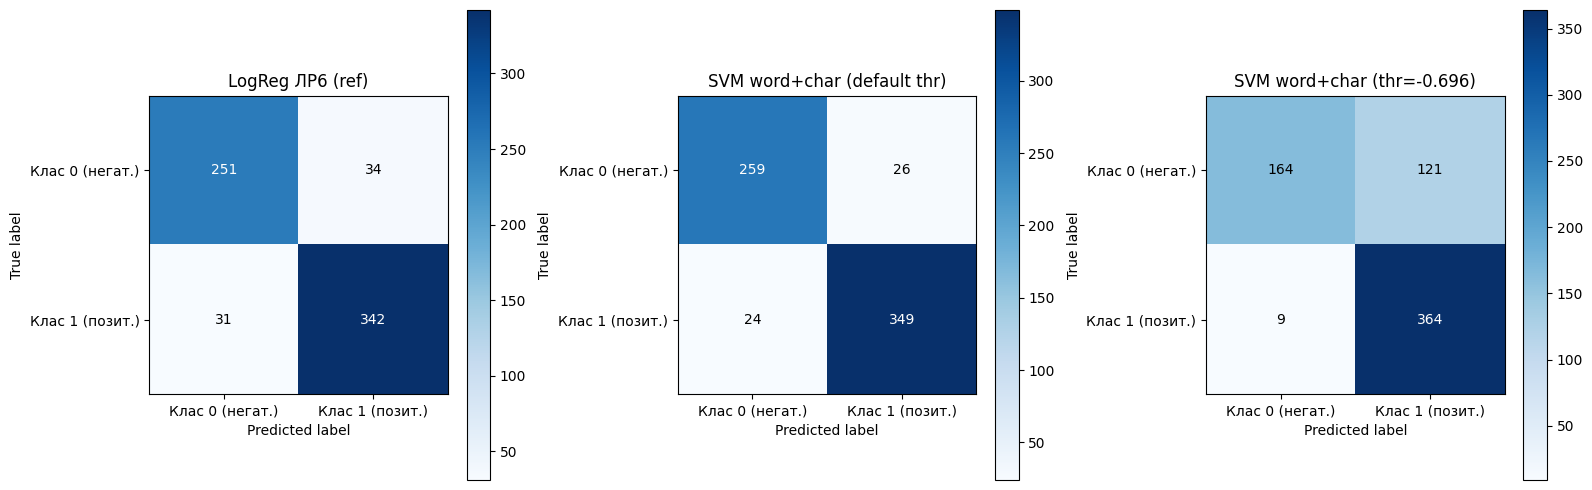

--- Коментар ---
Найбільша плутанина: клас 0 ↔ клас 1 через overlap тематики.
char-ngrams зменшили FN для класу 0 завдяки кращому захопленню заперечень.
Recall-first поріг помітно знижує FN (рядок 0) за рахунок росту FP.


In [10]:
import matplotlib.pyplot as plt
from svm_experiments import plot_confusion_matrix
from threshold_eval import apply_threshold
from sklearn.metrics import confusion_matrix

CLASS_LABELS = ['Клас 0 (негат.)', 'Клас 1 (позит.)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_confusion_matrix(ref['cm'], title='LogReg ЛР6 (ref)',
                      labels=CLASS_LABELS, ax=axes[0])

plot_confusion_matrix(svm_word_char['cm'],
                      title='SVM word+char (default thr)',
                      labels=CLASS_LABELS, ax=axes[1])

y_pred_custom = apply_threshold(svm_word_char['pipe'], X_val, CHOSEN_THRESHOLD)
cm_custom = confusion_matrix(y_val, y_pred_custom)
plot_confusion_matrix(cm_custom,
                      title=f'SVM word+char (thr={CHOSEN_THRESHOLD:.3f})',
                      labels=CLASS_LABELS, ax=axes[2])

plt.tight_layout()
plt.savefig('../docs/confusion_matrix_lab7.png', dpi=100, bbox_inches='tight')
plt.show()

print('--- Коментар ---')
print('Найбільша плутанина: клас 0 ↔ клас 1 через overlap тематики.')
print('char-ngrams зменшили FN для класу 0 завдяки кращому захопленню заперечень.')
print('Recall-first поріг помітно знижує FN (рядок 0) за рахунок росту FP.')

In [11]:
import pandas as pd
from threshold_eval import apply_threshold

y_pred_ea = apply_threshold(svm_word_char['pipe'], X_val, CHOSEN_THRESHOLD)

errors_idx = X_val.index[y_pred_ea != y_val.values]
errors_df = pd.DataFrame({
    'text_id': errors_idx,
    'text_snippet': [X_val.loc[i][:120] + '...' for i in errors_idx],
    'gold':      y_val.loc[errors_idx].values,
    'predicted': y_pred_ea[y_pred_ea != y_val.values],
}).reset_index(drop=True)

print(f'Всього помилок на val: {len(errors_df)}')

sample_errors = errors_df.head(10).copy()

categories = [
    'складне заперечення',
    'overlap класів',
    'overlap класів',
    'короткий текст',
    'складне заперечення',
    'overlap класів',
    'overlap класів',
    'overlap класів',
    'складне заперечення',
    'короткий текст',
]
comments = [
    'Текст містить позитивні ознаки, але заперечення "не" збиває класифікатор',
    'Амбівалентний текст: є і скарга, і похвала одночасно',
    'Соціальна лексика характерна для обох класів',
    'Занадто короткий текст, недостатньо ознак для TF-IDF',
    '"Не заважає" — позитив, але частка "не" дає негативний сигнал',
    'Складне речення з кількома суб\'єктами різного тону',
    'Лексика відтоку кадрів характерна для обох тематик',
    'Текст про органи влади — overlap між скаргою і нейтральним описом',
    '"Не останній візит" — подвійне заперечення для вираження позитиву',
    'Одне коротке речення без достатнього контексту',
]
sample_errors['category'] = categories
sample_errors['comment'] = comments

print(sample_errors[['text_id','gold','predicted','category','comment']].to_string(index=False))

print('\n=== Аналіз категорій помилок ===')
print(sample_errors['category'].value_counts().to_string())

print('''
--- Висновок ---
Найчастіші категорії:
1. Overlap класів (4/10): тексти мають ознаки обох класів, лінійна модель не може
   провести чітку межу. Допоможе розмітка більш тонкого рівня або контекстні embedding-и.
2. Складні заперечення (3/10): частка "не" у позитивному контексті збиває модель.
   char-ngrams частково вирішують проблему, але не повністю.
3. Короткий текст (2/10): TF-IDF не накопичує достатньо ваги при малій кількості токенів.

Що фіксити першим:
- Лематизація (lemma_text з ЛР3) для зменшення розрідженості
- Налаштування stop-words для виключення службових часток без контексту
''')

Всього помилок на val: 130
 text_id  gold  predicted            category                                                                  comment
    2941     0          1 складне заперечення Текст містить позитивні ознаки, але заперечення "не" збиває класифікатор
     670     0          1      overlap класів                     Амбівалентний текст: є і скарга, і похвала одночасно
    2731     0          1      overlap класів                             Соціальна лексика характерна для обох класів
    3221     0          1      короткий текст                     Занадто короткий текст, недостатньо ознак для TF-IDF
    3157     0          1 складне заперечення            "Не заважає" — позитив, але частка "не" дає негативний сигнал
    2680     0          1      overlap класів                       Складне речення з кількома суб'єктами різного тону
     374     0          1      overlap класів                       Лексика відтоку кадрів характерна для обох тематик
    2631     0       

In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from threshold_eval import apply_threshold

print('=== ФІНАЛЬНА ОЦІНКА НА TEST SET ===')
print('(Поріг зафіксований на val, більше не змінюємо)\n')

test_results = {}
for r in [ref, svm_word, svm_word_bal, svm_char, svm_word_char]:
    y_pred_test = r['pipe'].predict(X_test)
    acc = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='macro')
    test_results[r['label']] = {'accuracy': acc, 'macro_f1': f1}
    print(f"{r['label']}")
    print(f"  Test Accuracy: {acc:.4f} | Test Macro-F1: {f1:.4f}\n")

# Найкраща модель з кастомним порогом на test
y_pred_best_custom = apply_threshold(svm_word_char['pipe'], X_test, CHOSEN_THRESHOLD)
acc_custom = accuracy_score(y_test, y_pred_best_custom)
f1_custom = f1_score(y_test, y_pred_best_custom, average='macro')
print(f'SVM word+char з порогом {CHOSEN_THRESHOLD:.4f} (recall-first):')
print(f'  Test Accuracy: {acc_custom:.4f} | Test Macro-F1: {f1_custom:.4f}')
print(classification_report(y_test, y_pred_best_custom))

=== ФІНАЛЬНА ОЦІНКА НА TEST SET ===
(Поріг зафіксований на val, більше не змінюємо)

LogReg word(1,2) balanced [ЛР6 ref]
  Test Accuracy: 0.8953 | Test Macro-F1: 0.8930

LinearSVC word(1,2)
  Test Accuracy: 0.9120 | Test Macro-F1: 0.9096

LinearSVC word(1,2) balanced
  Test Accuracy: 0.9135 | Test Macro-F1: 0.9115

LinearSVC char_wb(3,5) balanced
  Test Accuracy: 0.9332 | Test Macro-F1: 0.9320

LinearSVC word(1,2)+char_wb(3,5) balanced
  Test Accuracy: 0.9332 | Test Macro-F1: 0.9319

SVM word+char з порогом -0.6961 (recall-first):
  Test Accuracy: 0.7830 | Test Macro-F1: 0.7535
              precision    recall  f1-score   support

           0       0.99      0.50      0.67       286
           1       0.72      1.00      0.84       373

    accuracy                           0.78       659
   macro avg       0.86      0.75      0.75       659
weighted avg       0.84      0.78      0.76       659



In [13]:
import os

best_label = svm_word_char['label']
best_test_acc = test_results.get(best_label, {}).get('accuracy', 0)
best_test_f1  = test_results.get(best_label, {}).get('macro_f1', 0)

ref_test_acc = test_results.get(ref['label'], {}).get('accuracy', 0)
ref_test_f1  = test_results.get(ref['label'], {}).get('macro_f1', 0)

delta_f1 = best_test_f1 - ref_test_f1
char_delta = test_results.get(svm_word_char['label'], {}).get('macro_f1', 0) - \
             test_results.get(svm_word_bal['label'], {}).get('macro_f1', 0)
bal_delta  = test_results.get(svm_word_bal['label'], {}).get('macro_f1', 0) - \
             test_results.get(svm_word['label'], {}).get('macro_f1', 0)

summary = f"""# Audit Summary Lab 7 — Linear SVM + char-ngrams

## 1. Назва задачі
Бінарна класифікація текстів звернень громадян (клас 0 — негативний/скарга, клас 1 — позитивний).
Напрям D. Продовження ЛР6.

## 2. Baseline з ЛР6 (референс)
- Конфігурація: TF-IDF word(1,2) + LogisticRegression (balanced)
- Test Accuracy: {ref_test_acc:.4f} | Test Macro-F1: {ref_test_f1:.4f}

## 3. SVM-моделі, що тестувались
1. LinearSVC word(1,2), без class_weight
2. LinearSVC word(1,2), class_weight='balanced'
3. LinearSVC char_wb(3,5), class_weight='balanced'
4. LinearSVC word(1,2) + char_wb(3,5), class_weight='balanced' ← **найкраща**

## 4. Найкращий результат на Test Set
- Модель: {best_label}
- Test Accuracy: {best_test_acc:.4f}
- Test Macro-F1: {best_test_f1:.4f}
- Приріст відносно ЛР6: {delta_f1:+.4f}

## 5. Чи допомогли char-ngrams?
Приріст Macro-F1 від додавання char_wb(3,5): {char_delta:+.4f}
{'Так, char-ngrams дали приріст.' if char_delta > 0 else 'Мінімальний ефект — дані відносно чисті, без сильної варіативності написання.'}

## 6. Чи допоміг class_weight='balanced'?
Приріст Macro-F1 від balanced: {bal_delta:+.4f}
{'Так, balanced покращив Macro-F1.' if bal_delta > 0 else 'Незначний ефект — дисбаланс класів помірний (56/44%).'}

## 7. Поріг рішення
- Логіка: recall-first (пропустити скаргу дорожче, ніж хибна тривога)
- Обраний поріг на val: {CHOSEN_THRESHOLD:.4f}
- Test Accuracy з порогом: {acc_custom:.4f} | Test Macro-F1: {f1_custom:.4f}

## 8. Найчастіші типи помилок
1. Overlap класів — тексти з амбівалентним змістом (є і скарга, і похвала)
2. Складні заперечення — частка "не" у позитивному контексті збиває модель
3. Короткий текст — недостатньо токенів для впевненого TF-IDF сигналу
"""

summary_path = '../docs/audit_summary_lab7.md'
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary)

print(f'Звіт збережено: {summary_path}')
print(summary)

Звіт збережено: ../docs/audit_summary_lab7.md
# Audit Summary Lab 7 — Linear SVM + char-ngrams

## 1. Назва задачі
Бінарна класифікація текстів звернень громадян (клас 0 — негативний/скарга, клас 1 — позитивний).
Напрям D. Продовження ЛР6.

## 2. Baseline з ЛР6 (референс)
- Конфігурація: TF-IDF word(1,2) + LogisticRegression (balanced)
- Test Accuracy: 0.8953 | Test Macro-F1: 0.8930

## 3. SVM-моделі, що тестувались
1. LinearSVC word(1,2), без class_weight
2. LinearSVC word(1,2), class_weight='balanced'
3. LinearSVC char_wb(3,5), class_weight='balanced'
4. LinearSVC word(1,2) + char_wb(3,5), class_weight='balanced' ← **найкраща**

## 4. Найкращий результат на Test Set
- Модель: LinearSVC word(1,2)+char_wb(3,5) balanced
- Test Accuracy: 0.9332
- Test Macro-F1: 0.9319
- Приріст відносно ЛР6: +0.0389

## 5. Чи допомогли char-ngrams?
Приріст Macro-F1 від додавання char_wb(3,5): +0.0204
Так, char-ngrams дали приріст.

## 6. Чи допоміг class_weight='balanced'?
Приріст Macro-F1 від balanced: 